<a href="https://colab.research.google.com/github/av1ary/Python-Projects/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data preparation

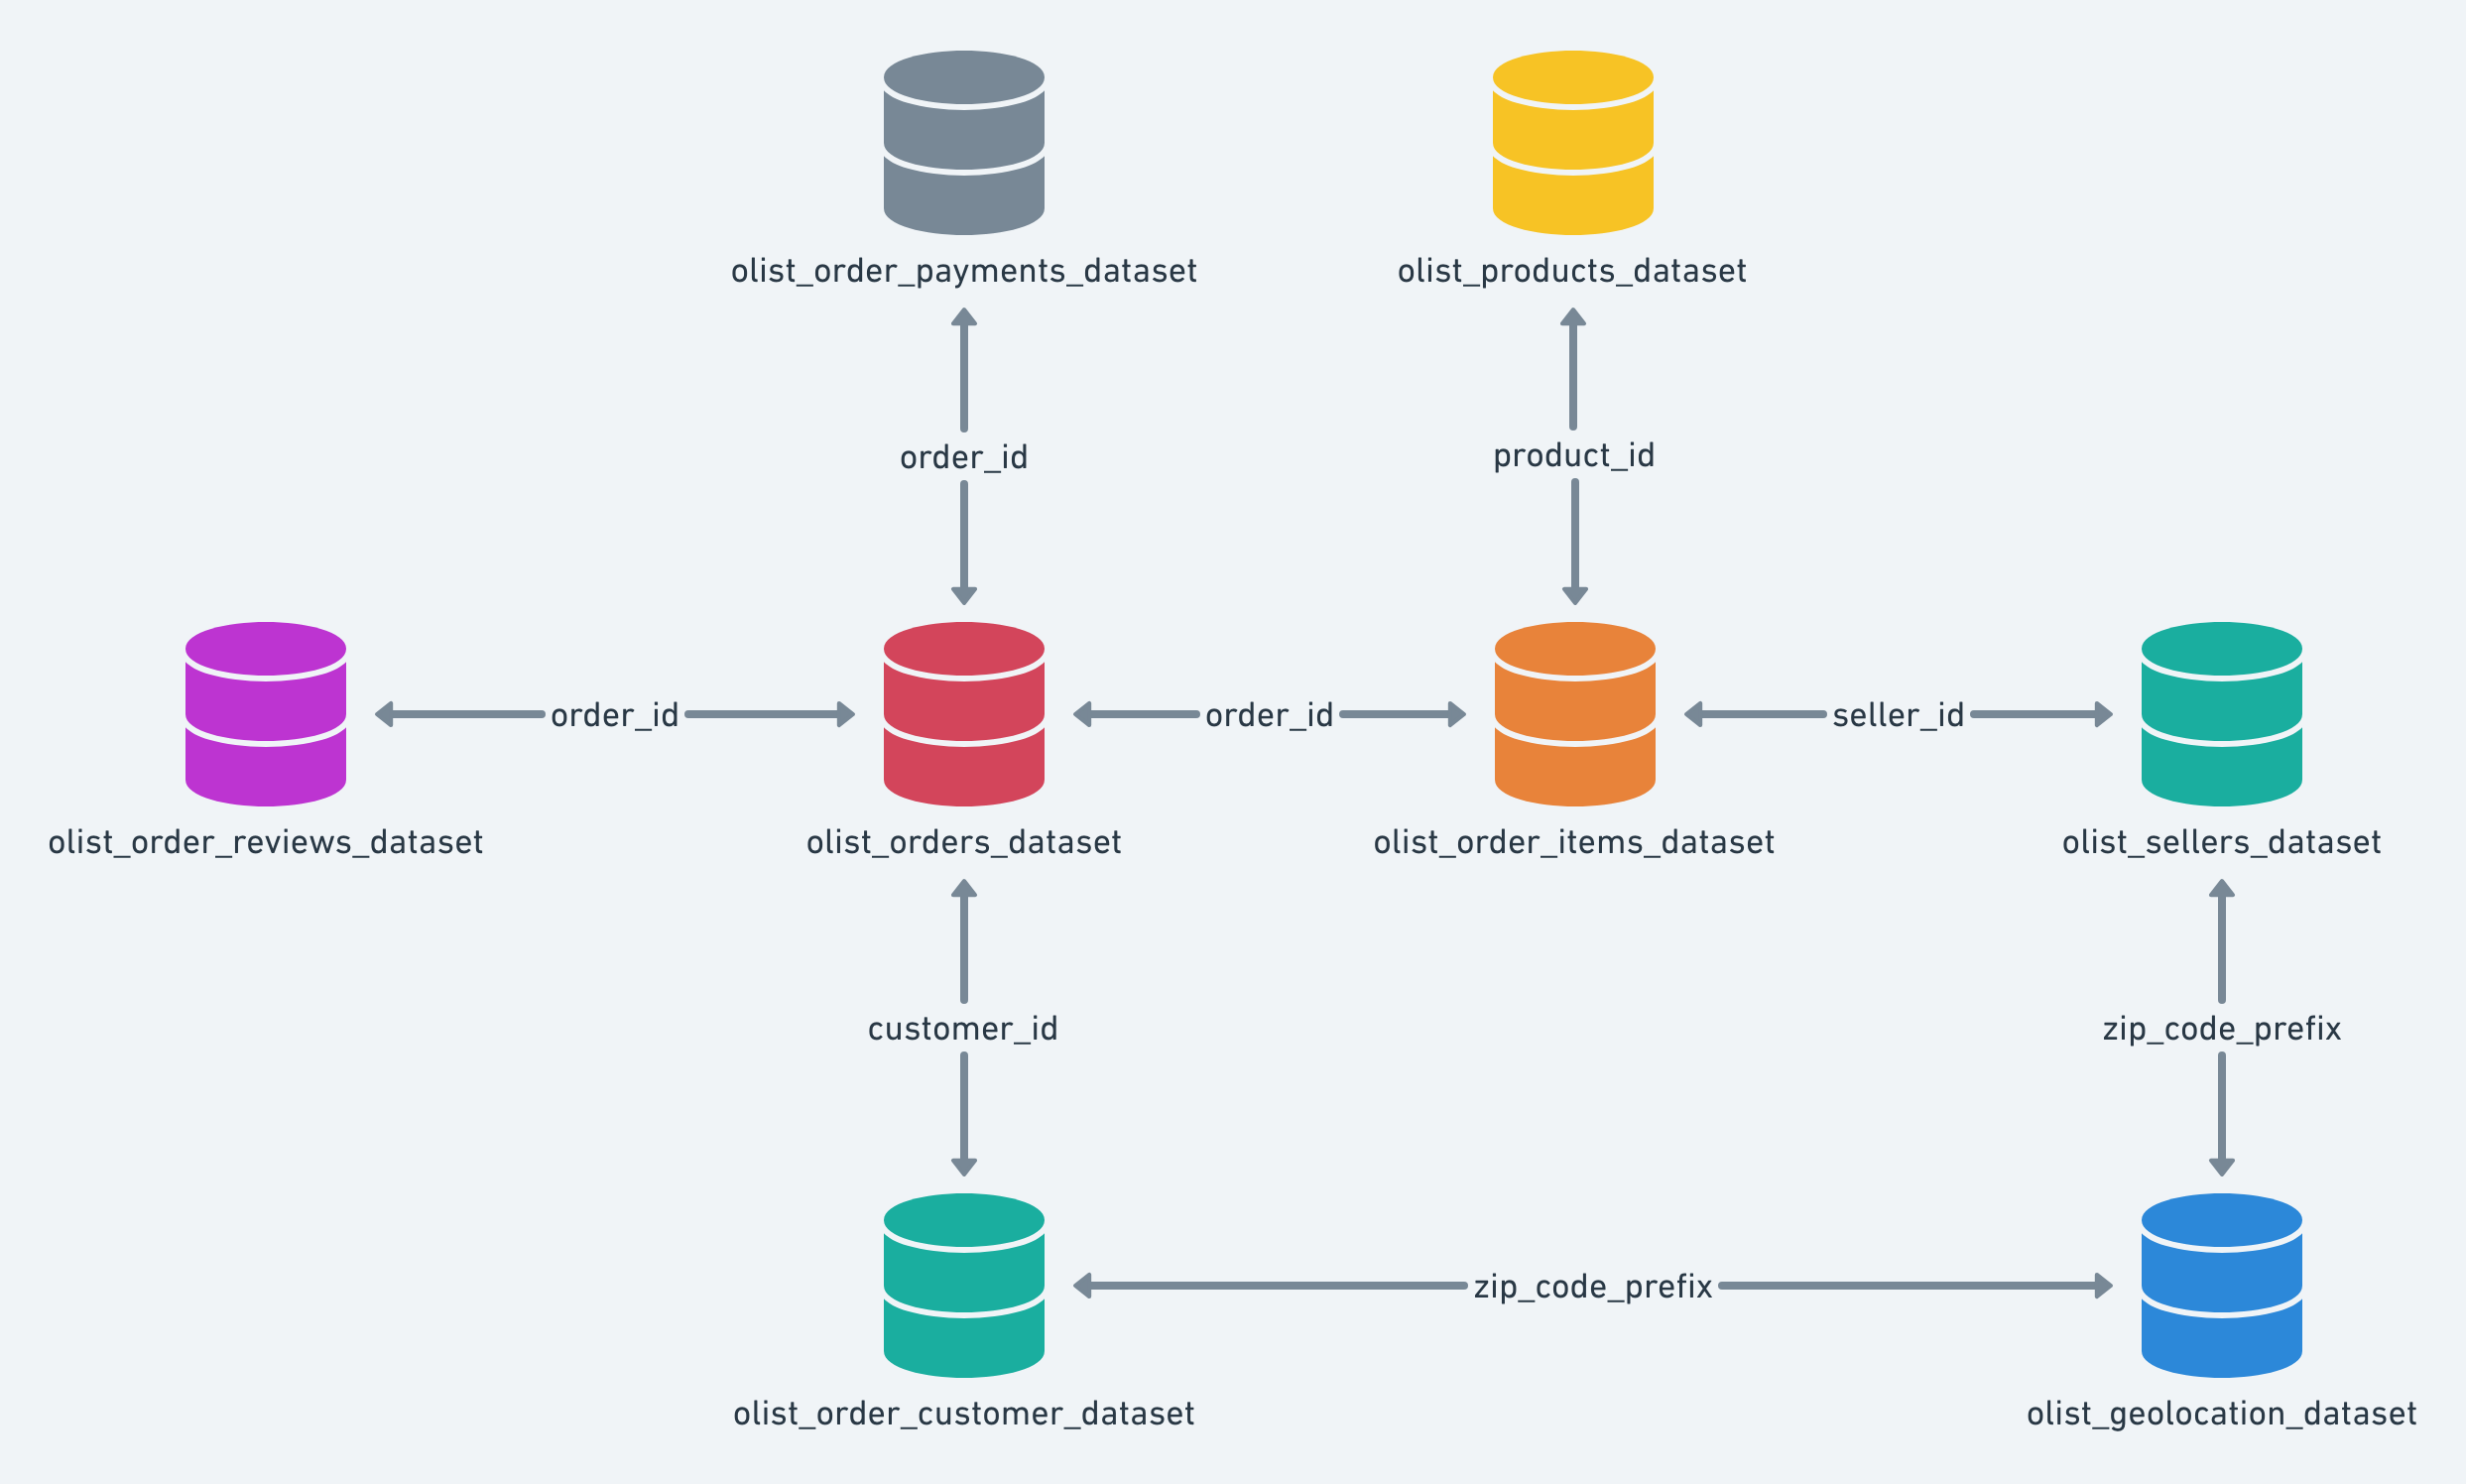

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
# Download data from kaggle
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
# reading all data
orders = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv",
                     parse_dates=True)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
order_items = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
products = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
order_payments = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")
order_payments .head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
customers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
geolocation = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv")
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
sellers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv")
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
product_category_name_translation = pd.read_csv("/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv")
product_category_name_translation.head()
# not going to use this table

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# checking the data for nulls and other data
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


the final table I need
Order date in week
product
seller id
seller city
seller state
product id
product category
customer city
customer state
So I will be able to predict the demand for product in each state/city for each seller

In [ ]:
orders.order_status.value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
# i need only delivered data,
# other statuses should be analysed in another research
orders=orders[orders['order_status']== 'delivered']
orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [ ]:
# i predict only weely sales, thus add new column with week start date
# then dropping everything else
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['week_start'] = orders['order_purchase_timestamp'].dt.normalize() - pd.to_timedelta(orders['order_purchase_timestamp'].dt.dayofweek, unit='d')
orders_weeked=orders[['order_id','customer_id','week_start']]
orders_weeked

,order_id,customer_id,week_start
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-23
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-06
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-12
...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-06
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-05
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-21
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08


In [ ]:
# adding information about items, products, sellers, customers, prices, etc
week_items=orders_weeked.merge(order_items,on='order_id',how='inner')
week_items=week_items.merge(products,on='product_id',how='inner')
week_items=week_items.merge(sellers,on='seller_id',how='inner')
week_items=week_items.merge(customers,on='customer_id',how='inner')
week_items

,order_id,customer_id,week_start,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-23,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,...,19.0,13.0,19.0,31570,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-06,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,...,24.0,19.0,21.0,14840,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-13,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,...,30.0,10.0,20.0,31842,belo horizonte,MG,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-12,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,...,51.0,15.0,15.0,8752,mogi das cruzes,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-05,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,...,40.0,10.0,40.0,17602,tupa,SP,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
110193,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-21,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,eletrodomesticos_2,...,32.0,90.0,22.0,8290,sao paulo,SP,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
110194,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,...,20.0,20.0,20.0,37175,ilicinea,MG,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ
110195,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,...,20.0,20.0,20.0,37175,ilicinea,MG,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [ ]:
# dropping unneeded data
pre_final=week_items[['week_start','product_category_name','order_id','product_id','price','seller_state','seller_id','customer_state']]
pre_final

,week_start,product_category_name,order_id,product_id,price,seller_state,seller_id,customer_state
0,2017-10-02,utilidades_domesticas,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,SP,3504c0cb71d7fa48d967e0e4c94d59d9,SP
1,2018-07-23,perfumaria,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,118.70,SP,289cdb325fb7e7f891c38608bf9e0962,BA
2,2018-08-06,automotivo,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,159.90,SP,4869f7a5dfa277a7dca6462dcf3b52b2,GO
3,2017-11-13,pet_shop,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,MG,66922902710d126a0e7d26b0e3805106,RN
4,2018-02-12,papelaria,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,19.90,SP,2c9e548be18521d1c43cde1c582c6de8,SP
...,...,...,...,...,...,...,...,...
110192,2018-02-05,bebes,63943bddc261676b46f01ca7ac2f7bd8,f1d4ce8c6dd66c47bbaa8c6781c2a923,174.90,SP,1f9ab4708f3056ede07124aad39a2554,SP
110193,2017-08-21,eletrodomesticos_2,83c1379a015df1e13d02aae0204711ab,b80910977a37536adeddd63663f916ad,205.99,SP,d50d79cb34e38265a8649c383dcffd48,BA
110194,2018-01-08,informatica_acessorios,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,MG,a1043bafd471dff536d0c462352beb48,RJ
110195,2018-01-08,informatica_acessorios,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,MG,a1043bafd471dff536d0c462352beb48,RJ


In [ ]:
# aggregating data, because i do not specify the customer, only location data
pre_final=pre_final.groupby(['week_start','seller_id','product_category_name','product_id','price','seller_state','customer_state']).agg({'order_id':'count'})
pre_final = pre_final.reset_index().rename(columns={'order_id': 'orders_count'})
pre_final

,week_start,seller_id,product_category_name,product_id,price,seller_state,customer_state,orders_count
0,2016-09-12,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,5a6b04657a4c5ee34285d1e4619a96b4,44.99,PR,SP,3
1,2016-10-03,011b0eaba87386a2ae96a7d32bb531d1,beleza_saude,508d48ea59be64138f0015d2cb9c75e7,49.99,SP,MG,2
2,2016-10-03,01cf7e3d21494c41fb86034f2e714fa1,cool_stuff,a760ef0bb70c954d79e62ec6023d380c,69.90,PR,ES,1
3,2016-10-03,024b564ae893ce8e9bfa02c10a401ece,market_place,d9894482fba41f536a273ba2276d951f,77.90,SP,MA,6
4,2016-10-03,0336182e1b3e92f029d5354832045fdf,moveis_decoracao,57d9a5d185e8254383504f57c4b8ddcc,14.90,SP,SP,1
...,...,...,...,...,...,...,...,...
91211,2018-08-27,fa1c13f2614d7b5c4749cbc52fecda94,relogios_presentes,9865c67a74684715521d1e70226cce0b,169.80,SP,SP,1
91212,2018-08-27,fadb07c842a2aef5d5a676b85f220e71,esporte_lazer,cc419cef76963f8e0cde78157908a6c3,21.99,SP,SP,1
91213,2018-08-27,fd386aa7bed2af3c7035c65506c9b4a3,brinquedos,fd9becacfcf0cebb9756687af69c716a,25.99,SP,SP,1
91214,2018-08-27,fd386aa7bed2af3c7035c65506c9b4a3,informatica_acessorios,d53fa4385b1c7af4bc099d079edd4b32,19.00,SP,SP,1


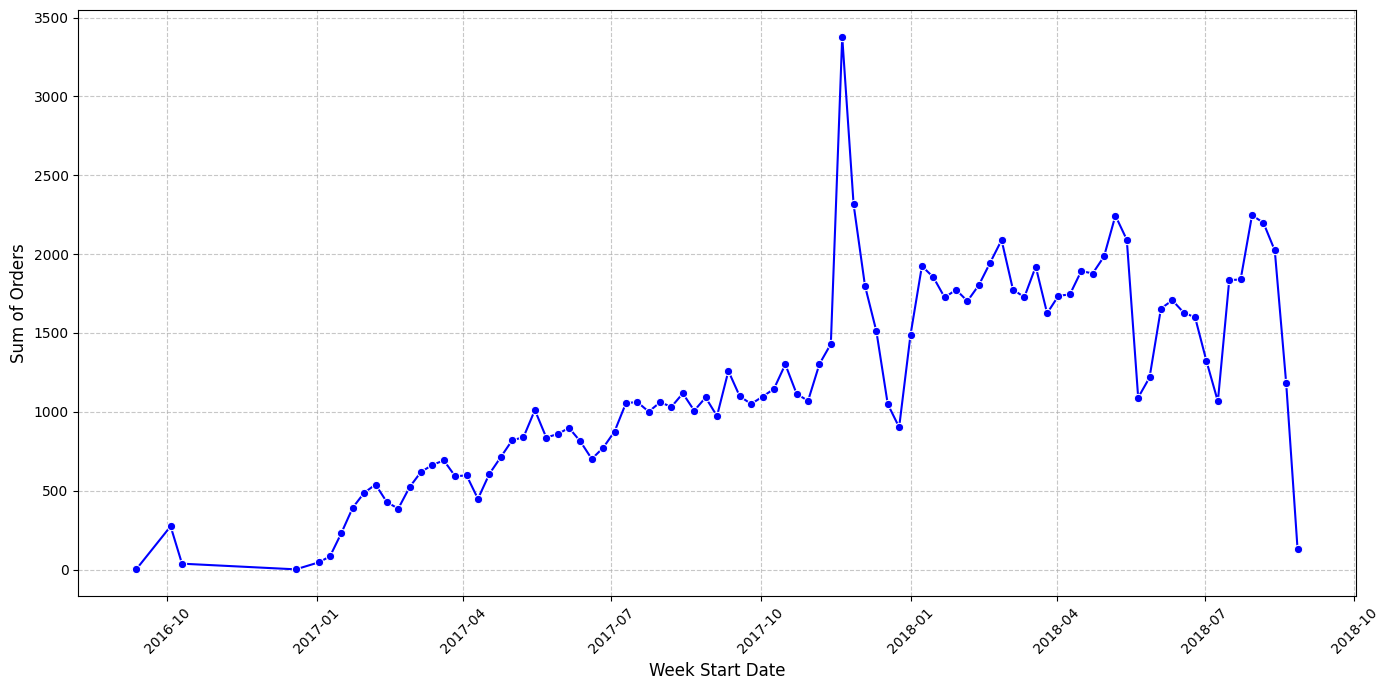

In [ ]:
# plotting the orders amount by week
weekly_trend = pre_final.groupby('week_start')['orders_count'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=weekly_trend, x='week_start', y='orders_count', marker='o', color='b')

plt.xlabel('Week Start Date', fontsize=12)
plt.ylabel('Sum of Orders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

last  week will be dropped - lack of data
pre last week will be used as test
Generally, i see a situation similar to most marketplaces - dynamic boost and then fluctuating.

In [ ]:
# checking for nulls
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91216 entries, 0 to 91215
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91216 non-null  datetime64[ns]
 1   seller_id              91216 non-null  object        
 2   product_category_name  91216 non-null  object        
 3   product_id             91216 non-null  object        
 4   price                  91216 non-null  float64       
 5   seller_state           91216 non-null  object        
 6   customer_state         91216 non-null  object        
 7   orders_count           91216 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 5.6+ MB


In [ ]:
# dropping the last week
last_week=pre_final.week_start.max()
pre_final=pre_final[pre_final['week_start']!=last_week]
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91100 entries, 0 to 91099
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91100 non-null  datetime64[ns]
 1   seller_id              91100 non-null  object        
 2   product_category_name  91100 non-null  object        
 3   product_id             91100 non-null  object        
 4   price                  91100 non-null  float64       
 5   seller_state           91100 non-null  object        
 6   customer_state         91100 non-null  object        
 7   orders_count           91100 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 6.3+ MB


# EDA

sum order by week, seller city, category, price, customer city

In [ ]:
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91100 entries, 0 to 91099
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91100 non-null  datetime64[ns]
 1   seller_id              91100 non-null  object        
 2   product_category_name  91100 non-null  object        
 3   product_id             91100 non-null  object        
 4   price                  91100 non-null  float64       
 5   seller_state           91100 non-null  object        
 6   customer_state         91100 non-null  object        
 7   orders_count           91100 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 6.3+ MB


In [ ]:
pre_final.product_category_name.value_counts()

,count
product_category_name,
cama_mesa_banho,9207
beleza_saude,7865
esporte_lazer,7309
moveis_decoracao,6189
informatica_acessorios,5926
...,...
portateis_cozinha_e_preparadores_de_alimentos,11
cds_dvds_musicais,10
pc_gamer,7


There are 73 categories. It is too much for one hot and I do not want to use target because of data leakage. theoretically the best option is binar or label endonging. But the model will focus on LGBM and CatBoost, so there is no need to encode it.

In [ ]:
# changing the data type to category
pre_final['product_category_name'] = pre_final['product_category_name'].astype('category')
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91100 entries, 0 to 91099
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91100 non-null  datetime64[ns]
 1   seller_id              91100 non-null  object        
 2   product_category_name  91100 non-null  category      
 3   product_id             91100 non-null  object        
 4   price                  91100 non-null  float64       
 5   seller_state           91100 non-null  object        
 6   customer_state         91100 non-null  object        
 7   orders_count           91100 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 5.6+ MB


/tmp/ipykernel_36930/109852522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_final['product_category_name'] = pre_final['product_category_name'].astype('category')


In [ ]:
pre_final.seller_state.value_counts()

,count
seller_state,
SP,64399
MG,7269
PR,7190
RJ,3915
SC,3500
RS,1877
DF,766
BA,479
GO,446


In [ ]:
# changing the data type to category
pre_final['seller_state'] = pre_final['seller_state'].astype('category')
pre_final['customer_state'] = pre_final['customer_state'].astype('category')
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91100 entries, 0 to 91099
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91100 non-null  datetime64[ns]
 1   seller_id              91100 non-null  object        
 2   product_category_name  91100 non-null  category      
 3   product_id             91100 non-null  object        
 4   price                  91100 non-null  float64       
 5   seller_state           91100 non-null  category      
 6   customer_state         91100 non-null  category      
 7   orders_count           91100 non-null  int64         
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.4+ MB


/tmp/ipykernel_36930/137318587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_final['seller_state'] = pre_final['seller_state'].astype('category')
/tmp/ipykernel_36930/137318587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_final['customer_state'] = pre_final['customer_state'].astype('category')


/tmp/ipykernel_36930/3865858098.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_sales = pre_final.groupby('customer_state')['orders_count'].sum().sort_values(ascending=False).reset_index()
/tmp/ipykernel_36930/3865858098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='customer_state', y='orders_count', palette='magma')


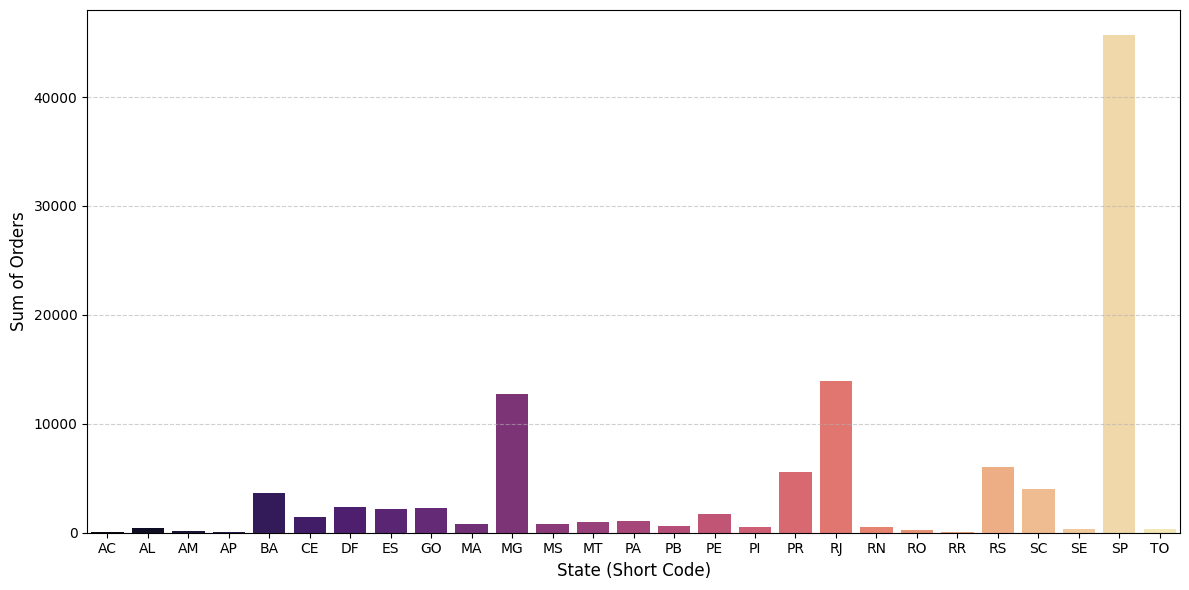

In [ ]:
# plotting the sales by states of customers
state_sales = pre_final.groupby('customer_state')['orders_count'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales, x='customer_state', y='orders_count', palette='magma')

plt.xlabel('State (Short Code)', fontsize=12)
plt.ylabel('Sum of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()


/tmp/ipykernel_36930/2002030391.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_sales = pre_final.groupby('seller_state')['orders_count'].sum().sort_values(ascending=False).reset_index()
/tmp/ipykernel_36930/2002030391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales, x='seller_state', y='orders_count', palette='magma')


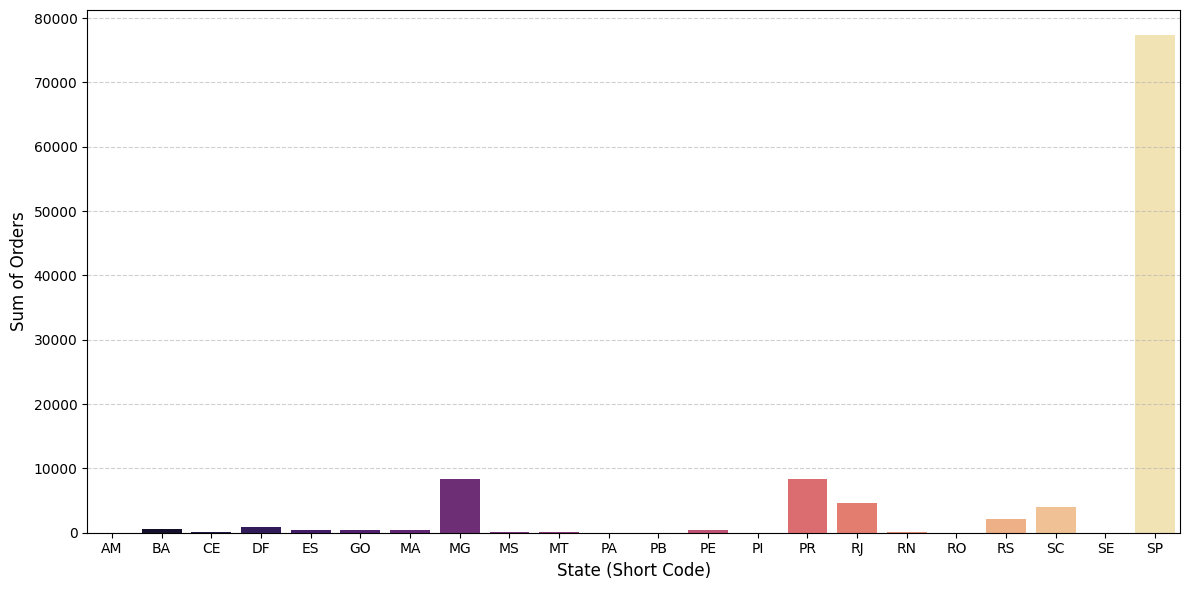

In [ ]:
# plotting the sales by states of sellers
state_sales = pre_final.groupby('seller_state')['orders_count'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales, x='seller_state', y='orders_count', palette='magma')

plt.xlabel('State (Short Code)', fontsize=12)
plt.ylabel('Sum of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()


In [ ]:
pre_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91100 entries, 0 to 91099
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             91100 non-null  datetime64[ns]
 1   seller_id              91100 non-null  object        
 2   product_category_name  91100 non-null  category      
 3   product_id             91100 non-null  object        
 4   price                  91100 non-null  float64       
 5   seller_state           91100 non-null  category      
 6   customer_state         91100 non-null  category      
 7   orders_count           91100 non-null  int64         
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.4+ MB


In [ ]:
# creating all combinations of product and weeks
all_weeks = pre_final['week_start'].unique()
all_products = pre_final['product_id'].unique()

index = pd.MultiIndex.from_product([all_weeks, all_products], names=['week_start', 'product_id'])
skeleton = pd.DataFrame(index=index).reset_index()

skeleton = skeleton.drop_duplicates()

In [ ]:
# adding product features to join for info with no sales
product_features = pre_final.groupby('product_id').agg({
    'product_category_name': 'first',
    'seller_id': 'first',
    'seller_state': 'first',
    'price': 'last'
}).reset_index()

In [ ]:
# adding real sales into skeleton
full_df = pd.merge(skeleton, pre_final, on=['week_start', 'product_id'], how='left')
full_df['orders_count'] = full_df['orders_count'].fillna(0)

In [ ]:
full_df

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count
0,2016-09-12,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,44.99,PR,SP,3.0
1,2016-09-12,508d48ea59be64138f0015d2cb9c75e7,NaN,NaN,NaN,NaN,NaN,0.0
2,2016-09-12,a760ef0bb70c954d79e62ec6023d380c,NaN,NaN,NaN,NaN,NaN,0.0
3,2016-09-12,d9894482fba41f536a273ba2276d951f,NaN,NaN,NaN,NaN,NaN,0.0
4,2016-09-12,57d9a5d185e8254383504f57c4b8ddcc,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...
2857736,2018-08-20,8a67e4e6cc6f2abf65fe2164ea51b219,fd386aa7bed2af3c7035c65506c9b4a3,agro_industria_e_comercio,12.99,SP,RJ,1.0
2857737,2018-08-20,e116e213716b7b91f8a320c37939ed17,fd386aa7bed2af3c7035c65506c9b4a3,utilidades_domesticas,23.80,SP,RJ,1.0
2857738,2018-08-20,b9471cbef91a12be725aa96bea7d4763,fd435faa3c0422b60440ea3480d0e77c,eletronicos,749.00,PB,RJ,1.0
2857739,2018-08-20,6def67bdc7378646b16c6efa3a78ba0b,ff063b022a9a0aab91bad2c9088760b7,industria_comercio_e_negocios,1230.00,SP,SP,1.0


In [ ]:
# changing product_id to category
full_df['product_id']=full_df['product_id'].astype('category')
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2857741 entries, 0 to 2857740
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             category      
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float64       
dtypes: category(4), datetime64[ns](1), float64(2), object(1)
memory usage: 102.1+ MB


In [ ]:
# real sales part
full_df_true=full_df[full_df['seller_id'].notnull()]
full_df_true

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count
0,2016-09-12,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,44.99,PR,SP,3.0
31591,2016-10-03,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,54.99,PR,PR,1.0
31592,2016-10-03,508d48ea59be64138f0015d2cb9c75e7,011b0eaba87386a2ae96a7d32bb531d1,beleza_saude,49.99,SP,MG,2.0
31593,2016-10-03,a760ef0bb70c954d79e62ec6023d380c,01cf7e3d21494c41fb86034f2e714fa1,cool_stuff,69.90,PR,ES,1.0
31594,2016-10-03,d9894482fba41f536a273ba2276d951f,024b564ae893ce8e9bfa02c10a401ece,market_place,77.90,SP,MA,6.0
...,...,...,...,...,...,...,...,...
2857736,2018-08-20,8a67e4e6cc6f2abf65fe2164ea51b219,fd386aa7bed2af3c7035c65506c9b4a3,agro_industria_e_comercio,12.99,SP,RJ,1.0
2857737,2018-08-20,e116e213716b7b91f8a320c37939ed17,fd386aa7bed2af3c7035c65506c9b4a3,utilidades_domesticas,23.80,SP,RJ,1.0
2857738,2018-08-20,b9471cbef91a12be725aa96bea7d4763,fd435faa3c0422b60440ea3480d0e77c,eletronicos,749.00,PB,RJ,1.0
2857739,2018-08-20,6def67bdc7378646b16c6efa3a78ba0b,ff063b022a9a0aab91bad2c9088760b7,industria_comercio_e_negocios,1230.00,SP,SP,1.0


In [ ]:
# syntetic no sales data and their product features.
full_df_synt=full_df[full_df['seller_id'].isnull()]
full_df_synt=full_df_synt[['week_start','product_id','orders_count']]
full_df_synt=full_df_synt.merge(product_features,on='product_id',how='left')
full_df_synt

,week_start,product_id,orders_count,product_category_name,seller_id,seller_state,price
0,2016-09-12,508d48ea59be64138f0015d2cb9c75e7,0.0,beleza_saude,011b0eaba87386a2ae96a7d32bb531d1,SP,49.99
1,2016-09-12,a760ef0bb70c954d79e62ec6023d380c,0.0,cool_stuff,01cf7e3d21494c41fb86034f2e714fa1,PR,76.05
2,2016-09-12,d9894482fba41f536a273ba2276d951f,0.0,market_place,024b564ae893ce8e9bfa02c10a401ece,SP,77.90
3,2016-09-12,57d9a5d185e8254383504f57c4b8ddcc,0.0,moveis_decoracao,0336182e1b3e92f029d5354832045fdf,SP,14.90
4,2016-09-12,ace91f88d635b9e5563e36cc0a0a8f09,0.0,moveis_decoracao,0336182e1b3e92f029d5354832045fdf,SP,14.90
...,...,...,...,...,...,...,...
2766636,2018-08-20,918bc9631b98fd39f5c52c9d11cc0597,0.0,utilidades_domesticas,febab0275244b9a49a623f0bd613ca2f,SP,126.80
2766637,2018-08-20,8c7442b088dc69fece3db05b53234860,0.0,automotivo,ffa6adafb71b807dc13159e26431354c,PR,139.00
2766638,2018-08-20,a6fb3c4f1816d9e2f52ff88e46c114f2,0.0,automotivo,ffa6adafb71b807dc13159e26431354c,PR,149.00
2766639,2018-08-20,3708b9e82cab4cd6e94e11a9919b1f8a,0.0,moveis_decoracao,ffc470761de7d0232558ba5e786e57b7,SP,25.90


In [ ]:
# concating synt and real sales data
full_df=pd.concat([full_df_true,full_df_synt])
full_df

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count
0,2016-09-12,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,44.99,PR,SP,3.0
31591,2016-10-03,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,beleza_saude,54.99,PR,PR,1.0
31592,2016-10-03,508d48ea59be64138f0015d2cb9c75e7,011b0eaba87386a2ae96a7d32bb531d1,beleza_saude,49.99,SP,MG,2.0
31593,2016-10-03,a760ef0bb70c954d79e62ec6023d380c,01cf7e3d21494c41fb86034f2e714fa1,cool_stuff,69.90,PR,ES,1.0
31594,2016-10-03,d9894482fba41f536a273ba2276d951f,024b564ae893ce8e9bfa02c10a401ece,market_place,77.90,SP,MA,6.0
...,...,...,...,...,...,...,...,...
2766636,2018-08-20,918bc9631b98fd39f5c52c9d11cc0597,febab0275244b9a49a623f0bd613ca2f,utilidades_domesticas,126.80,SP,NaN,0.0
2766637,2018-08-20,8c7442b088dc69fece3db05b53234860,ffa6adafb71b807dc13159e26431354c,automotivo,139.00,PR,NaN,0.0
2766638,2018-08-20,a6fb3c4f1816d9e2f52ff88e46c114f2,ffa6adafb71b807dc13159e26431354c,automotivo,149.00,PR,NaN,0.0
2766639,2018-08-20,3708b9e82cab4cd6e94e11a9919b1f8a,ffc470761de7d0232558ba5e786e57b7,moveis_decoracao,25.90,SP,NaN,0.0


In [ ]:
# checking for datatype. week start will be dropped after feature enginering
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 0 to 2766640
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float64       
dtypes: category(3), datetime64[ns](1), float64(2), object(2)
memory usage: 139.0+ MB


In [ ]:
# no nee for such detailes
full_df.orders_count=full_df.orders_count.astype('float32')
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 0 to 2766640
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
dtypes: category(3), datetime64[ns](1), float32(1), float64(1), object(2)
memory usage: 128.1+ MB


# Feature engineering

The feature engineering will be manual, because an example of automated is given in another project.
Firstly I will create neew time columns for seasonality
Then create lag and rolling info, because relevance matters
Lastly create zero sales signal, because most data is no sales.

## Time-Based Features

In [ ]:
# function to craete new date columns
# such as month, week, year and quarter.
def create_time_features(df):
    df = df.copy()
    df['month'] = df['week_start'].dt.month
    df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['year'] = df['week_start'].dt.year

    df['quarter'] = df['week_start'].dt.quarter

    return df

In [ ]:
full_df = create_time_features(full_df)

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 0 to 2766640
Data columns (total 12 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   month                  int32         
 9   week_of_year           int64         
 10  year                   int32         
 11  quarter                int32         
dtypes: category(3), datetime64[ns](1), float32(1), float64(1), int32(3), int64(1), object(2)
memory usage: 182.6+ MB


In [ ]:
# it is needed because the month and cyclical
# previus version will be dropped
full_df['month_sin'] = np.sin(2 * np.pi * full_df['month'] / 12)
full_df['month_cos'] = np.cos(2 * np.pi * full_df['month'] / 12)

# the same for weeks
full_df['week_sin'] = np.sin(2 * np.pi * full_df['week_of_year'] / 52)
full_df['week_cos'] = np.cos(2 * np.pi * full_df['week_of_year'] / 52)

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 0 to 2766640
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   month                  int32         
 9   week_of_year           int64         
 10  year                   int32         
 11  quarter                int32         
 12  month_sin              float64       
 13  month_cos              float64       
 14  week_sin               float64       
 15  week_cos               float64       
dtypes: category(3), datetime64[ns](1), float32(1), float64(5), int32(3), int64(1), object(2)
memory usage: 269.8+ MB


In [ ]:
# droping non cyclical month data
full_df=full_df.drop(['month','week_of_year'],axis=1)
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 0 to 2766640
Data columns (total 14 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   quarter                int32         
 10  month_sin              float64       
 11  month_cos              float64       
 12  week_sin               float64       
 13  week_cos               float64       
dtypes: category(3), datetime64[ns](1), float32(1), float64(5), int32(2), object(2)
memory usage: 237.1+ MB


## Lag and Rolling Window Features

In [ ]:
# creating 1, 2 and 4(month) lag columns
full_df = full_df.sort_values(['product_id', 'week_start'])

for i in [1, 2, 4]:
    full_df[f'orders_lag_{i}'] = full_df.groupby('product_id')['orders_count'].shift(i)

full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 24891 to 2760534
Data columns (total 17 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   quarter                int32         
 10  month_sin              float64       
 11  month_cos              float64       
 12  week_sin               float64       
 13  week_cos               float64       
 14  orders_lag_1           float32       
 15  orders_lag_2           float32       
 16  orders_lag_4           float32       
dtypes: category(3), datetime64[ns](1), float32(4), float64(5), int32(2

In [ ]:
# rolling data is needed to check the relevant trend of sales

full_df['rolling_mean_4'] = full_df.groupby('product_id')['orders_count'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)

full_df['rolling_std_4'] = full_df.groupby('product_id')['orders_count'].transform(
    lambda x: x.shift(1).rolling(window=4).std()
)

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 24891 to 2760534
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   quarter                int32         
 10  month_sin              float64       
 11  month_cos              float64       
 12  week_sin               float64       
 13  week_cos               float64       
 14  orders_lag_1           float32       
 15  orders_lag_2           float32       
 16  orders_lag_4           float32       
 17  rolling_mean_4         float64       
 18  rolling_std_4          

In [ ]:
full_df

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count,year,quarter,month_sin,month_cos,week_sin,week_cos,orders_lag_1,orders_lag_2,orders_lag_4,rolling_mean_4,rolling_std_4
24891,2016-09-12,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,3,-1.000000e+00,-1.836970e-16,-0.970942,-0.239316,NaN,NaN,NaN,NaN,NaN
56276,2016-10-03,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,-8.660254e-01,5.000000e-01,-0.992709,0.120537,0.0,NaN,NaN,NaN,NaN
87833,2016-10-10,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,-8.660254e-01,5.000000e-01,-0.970942,0.239316,0.0,0.0,NaN,NaN,NaN
119423,2016-12-19,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,-2.449294e-16,1.000000e+00,-0.120537,0.992709,0.0,0.0,NaN,NaN,NaN
150985,2017-01-02,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,5.000000e-01,8.660254e-01,0.120537,0.992709,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2639977,2018-07-23,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,-5.000000e-01,-8.660254e-01,-0.464723,-0.885456,0.0,0.0,0.0,0.0,0.0
2670141,2018-07-30,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,-5.000000e-01,-8.660254e-01,-0.568065,-0.822984,0.0,0.0,0.0,0.0,0.0
2700137,2018-08-06,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,-8.660254e-01,-5.000000e-01,-0.663123,-0.748511,0.0,0.0,0.0,0.0,0.0
2730235,2018-08-13,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,-8.660254e-01,-5.000000e-01,-0.748511,-0.663123,0.0,0.0,0.0,0.0,0.0


## Zero Sales signal

In [ ]:
# here I create three columns for zero sales signal
# if there was a sale last week
full_df['is_active_last_week'] = (full_df['orders_lag_1'] > 0).astype(int)
#  all sales till this day
full_df['total_sales_to_date'] = full_df.groupby('product_id')['orders_count'].cumsum() - full_df['orders_count']
# sales probabily for product
full_df['sale_probability'] = full_df.groupby('product_id')['orders_count'].transform(
    lambda x: (x.shift(1) > 0).expanding().mean()
)
# in reality it should be more complicated

In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2857741 entries, 24891 to 2760534
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             object        
 2   seller_id              object        
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   quarter                int32         
 10  month_sin              float64       
 11  month_cos              float64       
 12  week_sin               float64       
 13  week_cos               float64       
 14  orders_lag_1           float32       
 15  orders_lag_2           float32       
 16  orders_lag_4           float32       
 17  rolling_mean_4         float64       
 18  rolling_std_4          

In [ ]:
full_df

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count,year,quarter,...,week_sin,week_cos,orders_lag_1,orders_lag_2,orders_lag_4,rolling_mean_4,rolling_std_4,is_active_last_week,total_sales_to_date,sale_probability
24891,2016-09-12,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,3,...,-0.970942,-0.239316,NaN,NaN,NaN,NaN,NaN,0,0.0,0.000000
56276,2016-10-03,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,...,-0.992709,0.120537,0.0,NaN,NaN,NaN,NaN,0,0.0,0.000000
87833,2016-10-10,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,...,-0.970942,0.239316,0.0,0.0,NaN,NaN,NaN,0,0.0,0.000000
119423,2016-12-19,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2016,4,...,-0.120537,0.992709,0.0,0.0,NaN,NaN,NaN,0,0.0,0.000000
150985,2017-01-02,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.120537,0.992709,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2639977,2018-07-23,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.464723,-0.885456,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011628
2670141,2018-07-30,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.568065,-0.822984,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011494
2700137,2018-08-06,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.663123,-0.748511,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011364
2730235,2018-08-13,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.748511,-0.663123,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011236


#Data preparatoin

In [ ]:
# dropping the very first sales for prooduct
full_df = full_df.dropna(subset=['orders_lag_4'])

In [ ]:
full_df

,week_start,product_id,seller_id,product_category_name,price,seller_state,customer_state,orders_count,year,quarter,...,week_sin,week_cos,orders_lag_1,orders_lag_2,orders_lag_4,rolling_mean_4,rolling_std_4,is_active_last_week,total_sales_to_date,sale_probability
150985,2017-01-02,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.120537,0.992709,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
182510,2017-01-09,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.239316,0.970942,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
213933,2017-01-16,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.354605,0.935016,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
245249,2017-01-23,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.464723,0.885456,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
276501,2017-01-30,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,perfumaria,101.65,SP,NaN,0.0,2017,1,...,0.568065,0.822984,0.0,0.0,0.0,0.0,0.0,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609701,2018-07-16,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.354605,-0.935016,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011765
2639977,2018-07-23,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.464723,-0.885456,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011628
2670141,2018-07-30,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.568065,-0.822984,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011494
2700137,2018-08-06,fffe9eeff12fcbd74a2f2b007dde0c58,7299e27ed73d2ad986de7f7c77d919fa,brinquedos,249.99,MG,NaN,0.0,2018,3,...,-0.663123,-0.748511,0.0,0.0,0.0,0.0,0.0,0,1.0,0.011364


In [ ]:
# changing the types for product and seller id
full_df['product_id'] = full_df['product_id'].astype('category')
full_df['seller_id'] = full_df['seller_id'].astype('category')

In [ ]:
# cutoff date for train and validation split
cutoff_date = full_df['week_start'].max() - pd.Timedelta(weeks=4)

In [ ]:
# train and test splitting
train = full_df[full_df['week_start'] < cutoff_date].copy()
val = full_df[full_df['week_start'] >= cutoff_date].copy()

print(f"Training rows: {train.shape[0]}")
print(f"Validation rows: {val.shape[0]}")

Training rows: 2540455
Validation rows: 159244


In [ ]:
# we drop week_start for train and val, but the main df it is still needed
train=train.drop(columns=['week_start'])
val=val.drop(columns=['week_start'])

In [ ]:
# divide train and val for features and target
X_train = train.drop(columns=['orders_count'])
y_train = train['orders_count']

X_val = val.drop(columns=['orders_count'])
y_val = val['orders_count']

#Model tuning

In [ ]:
# I will focus on lgbm only, because it is just a best for now
# in reality i would compare several models, but the pet it is ok
import lightgbm as lgb

params = {
    'boosting_type': 'gbdt',
    'objective': 'poisson',      # Better for sales
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_jobs': -1,
    'verbosity': -1,
    'min_data_in_leaf': 100
}

In [ ]:
#  categorical features list
cat_features = ['product_id','seller_id','product_category_name',
                'seller_state', 'customer_state']

# Create dataset
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain,
                   categorical_feature=cat_features)

model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.17854	valid's rmse: 0.221533
[200]	train's rmse: 0.139895	valid's rmse: 0.176178
[300]	train's rmse: 0.119439	valid's rmse: 0.15536
[400]	train's rmse: 0.109113	valid's rmse: 0.147506
[500]	train's rmse: 0.103133	valid's rmse: 0.144075
[600]	train's rmse: 0.0991455	valid's rmse: 0.14266
[700]	train's rmse: 0.0963712	valid's rmse: 0.142128
[800]	train's rmse: 0.0943301	valid's rmse: 0.14192
Early stopping, best iteration is:
[799]	train's rmse: 0.0943437	valid's rmse: 0.141917


The model is little bit under fitted

In [ ]:
# the for sanity, because the dataset is unbalanced with many zeros
from sklearn.metrics import mean_squared_error

# array of zero
zero_baseline = np.zeros_like(y_val)

# Calculate the RMSE
baseline_rmse = np.sqrt(mean_squared_error(y_val, zero_baseline))

print(f"Model RMSE: {0.1419}") # Your best iteration
print(f"All-Zeros RMSE: {baseline_rmse:.6f}")

Model RMSE: 0.1419
All-Zeros RMSE: 0.310290


so the rmse makes sense, because of zero sales is more the twice worse

In [ ]:
# I love optuna for optimization
# because it also works with other problems
# not only ML
import optuna

def objective(trial):
    # hyperparameters to test
    param = {
        'objective': 'poisson',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 1000),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    # datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    # Training
    model = lgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

# Create a study and run for 20-30 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print(f"Best RMSE: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-04-25 18:49:48,733] A new study created in memory with name: no-name-1eb6a4a8-3738-4c57-9ce6-ba5dd6812fb7


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[400]	valid_0's rmse: 0.146029


[I 2026-04-25 18:53:29,903] Trial 0 finished with value: 0.14602873358230356 and parameters: {'learning_rate': 0.028888610996846725, 'num_leaves': 25, 'min_data_in_leaf': 766, 'lambda_l1': 0.001334170191941947, 'lambda_l2': 1.3118159986144777e-07, 'feature_fraction': 0.5726331704339179, 'bagging_fraction': 0.6420084672359512, 'bagging_freq': 7}. Best is trial 0 with value: 0.14602873358230356.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[436]	valid_0's rmse: 0.14278


[I 2026-04-25 18:56:40,786] Trial 1 finished with value: 0.14278049977635449 and parameters: {'learning_rate': 0.02035999283663053, 'num_leaves': 21, 'min_data_in_leaf': 988, 'lambda_l1': 2.117068784154221e-07, 'lambda_l2': 0.00014680490156148893, 'feature_fraction': 0.7424959548819883, 'bagging_fraction': 0.6367754073325655, 'bagging_freq': 4}. Best is trial 1 with value: 0.14278049977635449.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[114]	valid_0's rmse: 0.143663


[I 2026-04-25 20:08:09,959] Trial 28 finished with value: 0.14366305983898434 and parameters: {'learning_rate': 0.07088918565597747, 'num_leaves': 87, 'min_data_in_leaf': 100, 'lambda_l1': 3.4862852757578994e-07, 'lambda_l2': 0.025697003972196434, 'feature_fraction': 0.9070691964917139, 'bagging_fraction': 0.606548371473753, 'bagging_freq': 2}. Best is trial 6 with value: 0.14111737193551188.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[95]	valid_0's rmse: 0.143089


[I 2026-04-25 20:10:06,043] Trial 29 finished with value: 0.14308902271354287 and parameters: {'learning_rate': 0.0840357619718166, 'num_leaves': 195, 'min_data_in_leaf': 743, 'lambda_l1': 0.0005165254327323779, 'lambda_l2': 0.00047900710303321736, 'feature_fraction': 0.8407729060498932, 'bagging_fraction': 0.6779879539860738, 'bagging_freq': 7}. Best is trial 6 with value: 0.14111737193551188.


Best RMSE: 0.14111737193551188
Best Params: {'learning_rate': 0.02260825016822232, 'num_leaves': 139, 'min_data_in_leaf': 155, 'lambda_l1': 9.991653824997706e-08, 'lambda_l2': 3.577514858779267, 'feature_fraction': 0.9556325381781117, 'bagging_fraction': 0.5051362635526429, 'bagging_freq': 2}


Optimization gave us -0.0008

In [ ]:
# training final model with best params for feature importance check
final_params = {
    **study.best_params
}

X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

dtrain_final = lgb.Dataset(X_final, label=y_final,
                           categorical_feature=cat_features)

final_model = lgb.train(final_params, dtrain_final, num_boost_round=800)

# Feature importance

In [ ]:
# we could use direct feature importance or lime, but shap is standard i think
import shap

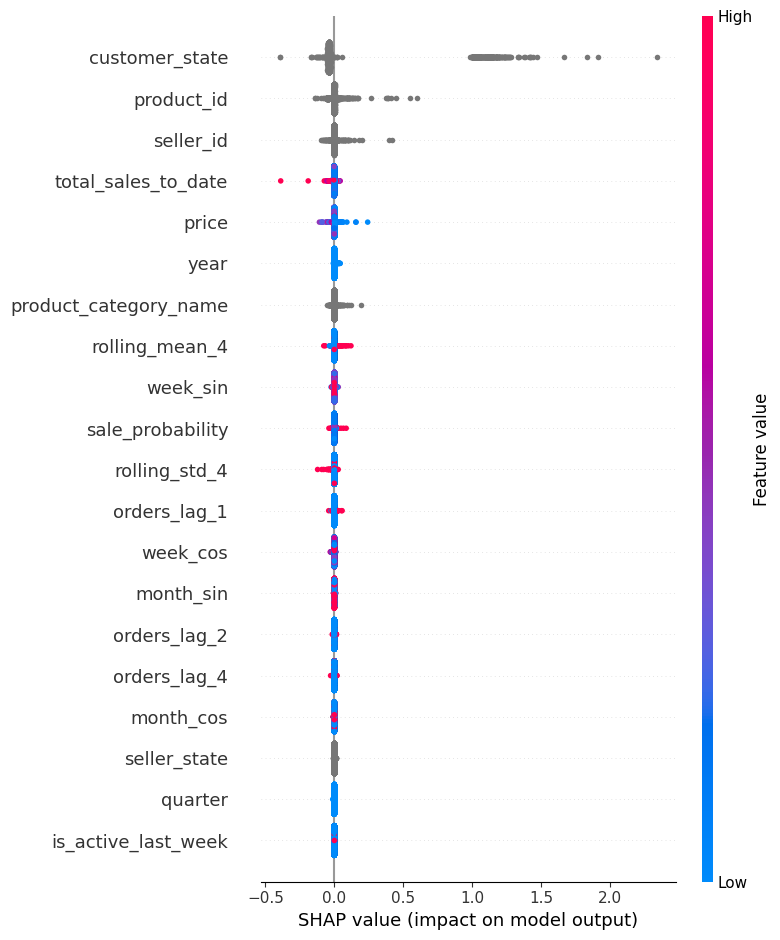

In [ ]:
# plotting efature importance
X_shap = X_val.sample(n=5000, random_state=18)

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)

I need to drop orders_lag_2, orders_lag_4 and is active_last_week and quarter. seller state reuires more investigations, probably seller and customer state much and so on, but for now i will not do anyting with it

In [ ]:
full_df=full_df.drop(columns=['orders_lag_2','orders_lag_4','is_active_last_week','quarter'])

#Adding elasticity into model

Elasticity is economic terms which defines te relationship between price and demand (sometimes even supply) for goods. But in competitive retail and ecom it is hardly simplifies, because custmers can compare prices and chose the cheapes. thus cheaper is almost always = better sales

In [ ]:
# the price of product compared to mean price of category
# people usually sort products by price and chose among the cheapest
full_df['rel_price_cat'] = full_df['price'] / full_df.groupby('product_category_name')['price'].transform('mean')

/tmp/ipykernel_36930/3490383051.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_df['rel_price_cat'] = full_df['price'] / full_df.groupby('product_category_name')['price'].transform('mean')


In [ ]:
# shows the price dynamics - growth and decline and its amount compared to the last week
full_df['price_diff_7d'] = full_df.groupby('product_id')['price'].diff()

/tmp/ipykernel_36930/1078460437.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_df['price_diff_7d'] = full_df.groupby('product_id')['price'].diff()


In [ ]:
# very similar the the first one, but ranked
full_df['price_rank'] = full_df.groupby('product_category_name')['price'].rank(pct=True)

/tmp/ipykernel_36930/4118042705.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_df['price_rank'] = full_df.groupby('product_category_name')['price'].rank(pct=True)


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2699699 entries, 150985 to 2730235
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             category      
 2   seller_id              category      
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   month_sin              float64       
 10  month_cos              float64       
 11  week_sin               float64       
 12  week_cos               float64       
 13  orders_lag_1           float32       
 14  rolling_mean_4         float64       
 15  rolling_std_4          float64       
 16  total_sales_to_date    float32       
 17  sale_probability       float64       
 18  rel_price_cat         

In [ ]:
# to much memory is used
full_df.month_sin=full_df.month_sin.astype('float32')
full_df.month_cos=full_df.month_cos.astype('float32')
full_df.week_sin=full_df.week_sin.astype('float32')
full_df.week_cos=full_df.week_cos.astype('float32')
full_df.rolling_mean_4=full_df.rolling_mean_4.astype('float32')
full_df.rolling_std_4=full_df.rolling_std_4.astype('float32')
full_df.sale_probability=full_df.sale_probability.astype('float32')
full_df.rel_price_cat=full_df.rel_price_cat.astype('float32')
full_df.price_diff_7d=full_df.price_diff_7d.astype('float32')
full_df.price_rank=full_df.price_rank.astype('float32')


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2699699 entries, 150985 to 2730235
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   week_start             datetime64[ns]
 1   product_id             category      
 2   seller_id              category      
 3   product_category_name  category      
 4   price                  float64       
 5   seller_state           category      
 6   customer_state         category      
 7   orders_count           float32       
 8   year                   int32         
 9   month_sin              float32       
 10  month_cos              float32       
 11  week_sin               float32       
 12  week_cos               float32       
 13  orders_lag_1           float32       
 14  rolling_mean_4         float32       
 15  rolling_std_4          float32       
 16  total_sales_to_date    float32       
 17  sale_probability       float32       
 18  rel_price_cat         

In [ ]:
# now it is ok

In [ ]:
# again cut off by week
train = full_df[full_df['week_start'] < cutoff_date].copy()
val = full_df[full_df['week_start'] >= cutoff_date].copy()

X_train = train.drop(columns=['orders_count','week_start'])
y_train = train['orders_count']

X_val = val.drop(columns=['orders_count','week_start'])
y_val = val['orders_count']

dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=cat_features)

In [ ]:
# train basic model
params = {
    'objective': 'poisson',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 127,          # Slightly higher to capture price interactions
    'min_data_in_leaf': 200,    # Good for your 2.8M rows
    'feature_fraction': 0.8,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l2': 0.5,           # Adding a bit of 'brakes' to prevent overfitting
    'verbosity': -1
}

model = lgb.train(
    params,
    dtrain,
    num_boost_round=1500,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.118863	valid's rmse: 0.158689
[200]	train's rmse: 0.0963149	valid's rmse: 0.144554
[300]	train's rmse: 0.0875372	valid's rmse: 0.143289
Early stopping, best iteration is:
[288]	train's rmse: 0.0887201	valid's rmse: 0.1431


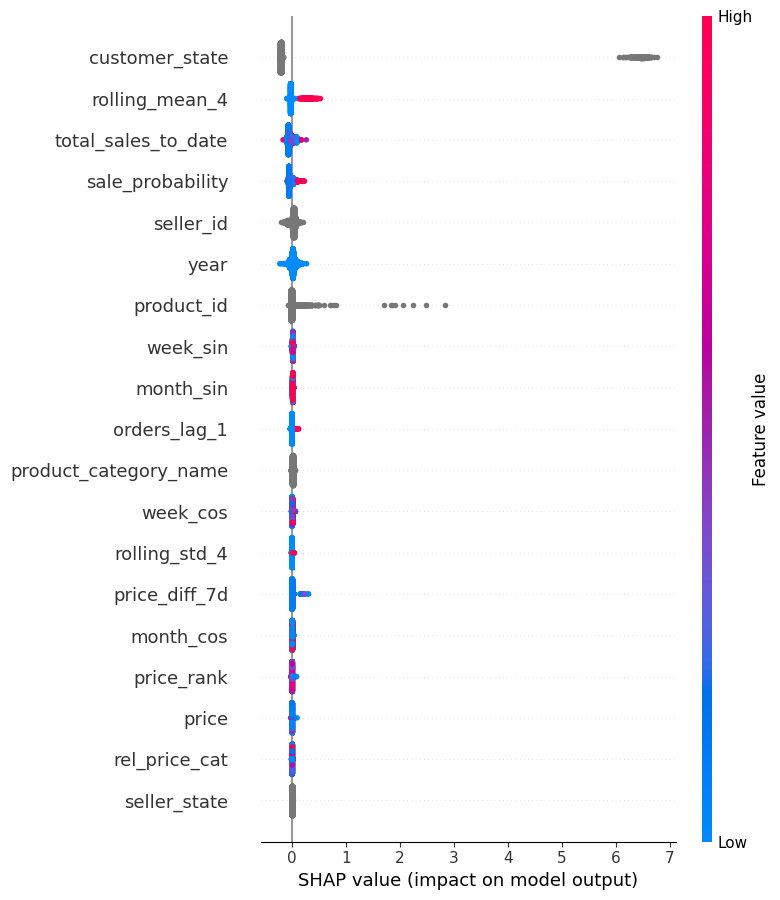

In [ ]:
# check the feature importance
X_shap = X_val.sample(n=5000, random_state=18)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)

In [ ]:
# all three new metrics showing the good results.

In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

def objective(trial):
    # hyperparameters to test
    param = {
        'objective': 'poisson',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 1000),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    #  datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    # Training
    model = lgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

# Create a study and run for 20-30 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print(f"Best RMSE: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-04-25 21:00:00,856] A new study created in memory with name: no-name-ff59d427-5568-4b22-8d0d-24f0dcbf3d71


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[192]	valid_0's rmse: 0.142253


[I 2026-04-25 21:02:20,324] Trial 0 finished with value: 0.14225304362666633 and parameters: {'learning_rate': 0.039185304079925064, 'num_leaves': 73, 'min_data_in_leaf': 514, 'lambda_l1': 3.3130170899014467e-08, 'lambda_l2': 5.8686228478902886e-08, 'feature_fraction': 0.8735997563806429, 'bagging_fraction': 0.7484796317955966, 'bagging_freq': 2}. Best is trial 0 with value: 0.14225304362666633.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[199]	valid_0's rmse: 0.142677


[I 2026-04-25 21:04:18,568] Trial 1 finished with value: 0.14267736353553062 and parameters: {'learning_rate': 0.04651105954044712, 'num_leaves': 63, 'min_data_in_leaf': 437, 'lambda_l1': 0.0020210915314890577, 'lambda_l2': 0.00012887614725966273, 'feature_fraction': 0.7152151859322089, 'bagging_fraction': 0.8091666453095094, 'bagging_freq': 1}. Best is trial 0 with value: 0.14225304362666633.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[278]	valid_0's rmse: 0.142295


[I 2026-04-25 22:56:49,989] Trial 28 finished with value: 0.1422949575471623 and parameters: {'learning_rate': 0.029201452645249187, 'num_leaves': 184, 'min_data_in_leaf': 711, 'lambda_l1': 1.8065054385484056, 'lambda_l2': 0.0034068113287065668, 'feature_fraction': 0.9056378328853478, 'bagging_fraction': 0.6523035847934993, 'bagging_freq': 2}. Best is trial 11 with value: 0.14092639777545427.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[201]	valid_0's rmse: 0.142185


[I 2026-04-25 22:59:35,147] Trial 29 finished with value: 0.14218517250680004 and parameters: {'learning_rate': 0.039585991439952145, 'num_leaves': 203, 'min_data_in_leaf': 420, 'lambda_l1': 6.108864145624772e-05, 'lambda_l2': 5.302712477419485e-08, 'feature_fraction': 0.9648112905756363, 'bagging_fraction': 0.7264234353167526, 'bagging_freq': 3}. Best is trial 11 with value: 0.14092639777545427.


Best RMSE: 0.14092639777545427
Best Params: {'learning_rate': 0.03739174152738049, 'num_leaves': 218, 'min_data_in_leaf': 126, 'lambda_l1': 5.0673210527995955, 'lambda_l2': 1.1872561889833428e-08, 'feature_fraction': 0.9839752222977056, 'bagging_fraction': 0.6836302059948989, 'bagging_freq': 1}


RMSE now is better than it was without elasticity by 0.0002. So the elasticity works and we need it in the model. However, there are problems with seller state and in te future, deeper work with it could make better results.